In [1]:
import qutip as qt
import numpy as np
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
import os
import math

#plt.rcParams['text.usetex'] = True
#rfont = {'fontname':'Times New Roman'}
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# Spin matrix
S0 = qt.qeye(3)                                                # {1, 0, -1}
Sx, Sy, Sz = qt.jmat(1)                                        # {1, 0, -1}
sigma0 = qt.qeye(2)                                            # {Ex, Ey}
sigmax, sigmay, sigmaz = qt.sigmax(), qt.sigmay(), qt.sigmaz() # {Ex, Ey}

# Physics constant
h             = 6.626e-34        # J/Hz
muB           = 9.274e-24 / h    # Hz/T
Des_para      = 1.42e9           # Hz       # [Doherty 2013], 1.44e9[Bassett 2014] 
Des_perp      = 1.55e9/2         # Hz       # [Doherty 2013], 1.541e9[Bassett 2014] 
lambdaes_para = 5.3e9            # Hz       # [Doherty 2013], 5.33e9[Bassett 2014]
lambdaes_perp = 0.2e9/np.sqrt(2) # Hz       # [Doherty 2013]
des_para      = 6e3              # Hz/(V/m) # [Doherty 2013]?
des_perp      = 6e3              # Hz/(V/m) # [Doherty 2013]?
les_para      = 0.1              # 1        # [Doherty 2013], 0.05[Bassett 2014] at 1.5K
ges_para      = 2.01             # 1        # [Doherty 2013], 2.15[Bassett 2014]
ges_perp      = 2.01             # 1        # [Doherty 2013]

In [2]:
# bare Hamiltonian
H_es = Des_para * qt.tensor(sigma0, Sz**2 - 2/3 * S0) \
       - lambdaes_para * qt.tensor(sigmay, Sz) \
       + Des_perp * (qt.tensor(sigmaz, Sy**2 - Sx**2) - qt.tensor(sigmax, Sy * Sx + Sx * Sy)) \
       + lambdaes_perp * (qt.tensor(sigmaz, Sx * Sz + Sz * Sx) - qt.tensor(sigmax, Sy * Sz + Sz * Sy))

# Interaction Hamiltonian
def V_es(E, B, delta):
    return des_para * (E[2] + delta[2]) * qt.tensor(sigma0, S0) \
           + des_perp * (E[0] + delta[0]) * qt.tensor(sigmaz, S0) \
           - des_perp * (E[1] + delta[1]) * qt.tensor(sigmax, S0) \
           + muB * (les_para * qt.tensor(sigmay, S0) + ges_para * qt.tensor(sigma0, Sz)) * B[2] \
           + muB * ges_perp * qt.tensor(sigma0, Sx * B[0] + Sy * B[1])


### stream line

1. Decpmpose eigenstates besed on spin basis
2. Extracting the amplitude coresponded to spin basis, resoectuvily
3. Define condition value ,Xi, which can reflect how spin basis are mixed , 
4. plot the normalized Xi  , sweeping magneticfield(para) and strain(perp)

In [3]:
# Decompostion of eigenstates based on spin basis
def Decomposition(H_tot):
    ee, ev = H_tot.eigenstates()
    ev_amp = [abs(evi.full()) for evi in ev][::-1]

    return ev_amp


# condition value
def Xi(List,i,j):
    a_i = List[i]
    a_j = List[j]

    return ( abs( abs(a_i)-abs(a_j) ) )/(abs(a_i) + abs(a_j) )


# Ductionary of ES and spin basis
Es = {'|A_2>': 0,'|A_1>': 1,'|E_x>': 2,'|E_y>': 3,'|E_1>': 4,'|E_2>': 5 }
spin_basis = {'a_0': 0,'a_1': 1,'a_2': 2,'a_3': 3,'a_4': 4,'a_5': 5 }




# extraction fot key 
def get_key_from_value(d, val):
    keys = [k for k, v in d.items() if v == val]
    if keys:
        return keys[0]
    return None

key1 = get_key_from_value(spin_basis, 1)
key1

'a_1'

The next code in the following cell is prototype.

could you save this for detecting error and discussing how to ammend 

In [ ]:
# Meshgrid parameters
E = [0,0,0]
strain_perp_values = np.linspace(0, 100e9, 100)
Bz_values = np.linspace(0, 1000e-4, 100)

# Allocate result matrix
xi_map = np.zeros((len(strain_perp_values), len(Bz_values)))
#highlight_points = []

# Evaluate Xi over parameter space
for k, strain_perp in enumerate(strain_perp_values):
    deltax = deltay = strain_perp / np.sqrt(2) / des_perp
    strain = [deltax, deltay, 0]

    for w, Bz in enumerate(Bz_values):
        B = [0, 0, Bz]
        H_tot = H_es + V_es(E, B, strain)

        amp_list = Decomposition(H_tot)[0]  # Assuming first eigenstate
        xi_val = Xi(amp_list, 1, 3)        

        xi_map[k, w] = xi_val

           # Overlay condition: amp[0]**2 + amp[2]**2 > 0.48
        #if amp_list[0] ** 2 + amp_list[2] ** 2 > 0.48:
            #highlight_points.append((
                #strain_perp / 1e9,  # x-axis in GPa
                #Bz * 1e4                  # y-axis in Gauss
            #))

# Normalize Xi map for better visualization
xi_map_norm = (xi_map - xi_map.min()) / (xi_map.max() - xi_map.min())

# Plotting the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(xi_map_norm, extent=[strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9, 
                                 Bz_values[0]*1e4, Bz_values[-1]*1e4],
           origin='lower', aspect='auto', cmap='viridis')

# Overlay scatter points
#highlight_points = np.array(highlight_points)
#if len(highlight_points) > 0:
    #plt.scatter(highlight_points[:, 0], highlight_points[:, 1],
                #color='red', s=10, label='|a₀|^2+|a₂|^2 > 0.45')

plt.colorbar(label='Normalized Xi')
plt.xlabel('Strain_perp (GPa)')
plt.ylabel('Bz (Gauss)')
plt.title('Mapping of Normalized Xi (|1⟩ vs |3⟩ component)')
plt.tight_layout()
plt.show()

SyntaxError: closing parenthesis '}' does not match opening parenthesis '[' (3667288997.py, line 22)

### the corresponding relationship about ES,and spin basis respectivily

H_tot[0] => $\ket{A_2}$,H_tot[1] => $\ket{A_1}$

H_tot[2] => $\ket{E_x}$,H_tot[3] => $\ket{E_y}$,

H_tot[4] => $\ket{E_1}$,H_tot[5] => $\ket{E_2}$

Some example

H_tot[0] = [$a_1$,$a_2$,$a_3$,$a_4$,$a_5$,$a_6$]

 => $\ket{A_2}$  = $a_1 \ket{E_x,+1} + a_2 \ket{E_x,0} + a_3 \ket{E_x,-1} 
                        +  a_4 \ket{E_y,+1} + a_5 \ket{E_y,0} + a_6 \ket{E_y,-1} $

But we should be carefule of swapping betweem eigenstate's labeling due to ESLAC

In [15]:
# Prototype 

# definition of making colormap, spni_basis. Now, we assuume i, j as labeling of spin basis
def making_colormap_spin_basis(spin_number,i,j,save_path=None):
    # Meshgrid parameters
    E = [0,0,0]
    strain_perp_values = np.linspace(0, 100e9, 100)
    Bz_values = np.linspace(0, 1000e-4, 100)

    # initialization 
    score = 0.0

    # Allocate result matrix
    xi_map = np.zeros((len(strain_perp_values), len(Bz_values)))
    #highlight_points = []

    # Evaluate Xi over parameter space
    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        strain = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, strain)

            amp_list = Decomposition(H_tot)[spin_number]  # Assuming first eigenstate
            diff = Xi(amp_list, i, j)         # Xi between 1st and 3rd components


            xi_map[k, w] = diff.item() if isinstance(diff, np.ndarray) else diff


        # Normalize Xi map for better visualization
    #xi_map_norm = (xi_map - xi_map.min()) / (xi_map.max() - xi_map.min())

    # Plotting the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(xi_map, extent=[strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9, 
                                    Bz_values[0]*1e4, Bz_values[-1]*1e4],
            origin='lower', aspect='auto', cmap='viridis')

    # Overlay scatter points
    #highlight_points = np.array(highlight_points)
    #if len(highlight_points) > 0:
        #plt.scatter(highlight_points[:, 0], highlight_points[:, 1],
                    #color='red', s=10, label='|a₀|^2+|a₂|^2 > 0.45')

    # converting spin_number => ES
    E_state = get_key_from_value(Es, spin_number)
    i_component = get_key_from_value(spin_basis, i)
    j_component = get_key_from_value(spin_basis, j)

    plt.colorbar(label='Normalized Xi')
    plt.xlabel('Strain_perp (GHz)')
    plt.ylabel('Bz (Gauss)')
    plt.title('Degree fo mixture of spin basis (%s vs %s component) in %s' %(i_component,j_component,E_state))
    plt.tight_layout()

     # Save or show the plot
    if save_path:
        filename = f"{save_path}/spin_mixture_{i}_{j}in_{E_state}.png"
        plt.savefig(filename)
        plt.close()
    else:
        plt.show()

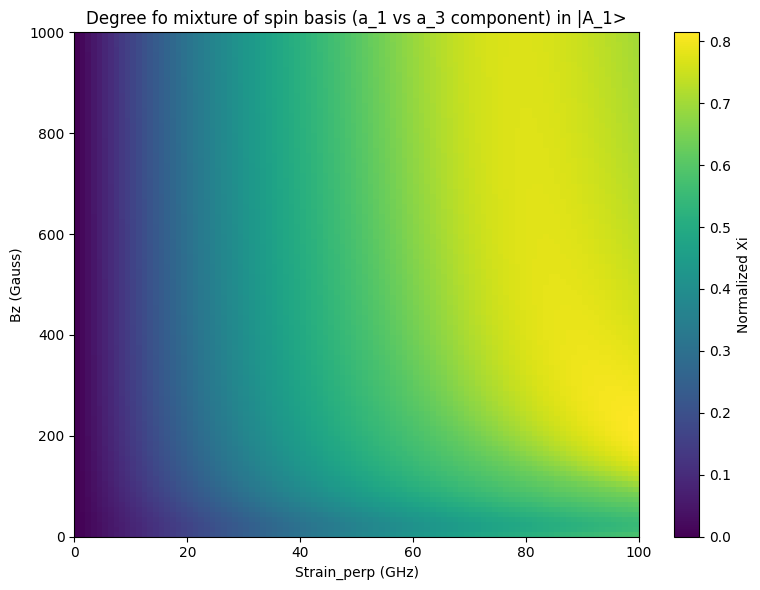

In [17]:

s = 1
making_colormap_spin_basis(s,1,3)

In [ ]:
save_dir = './colormap_outputs'
os.makedirs(save_dir, exist_ok=True)

start = 1
end = 6
for i in range(start,end + 1):
    for j in range(i,end + 1):
        if i != j:
            making_colormap_spin_basis(s, i, j, save_path=save_dir)

In [ ]:
save_dir = './colormap_outputs_$\ket{A_1}$'
os.makedirs(save_dir, exist_ok=True)
s = 1

start = 1
end = 6
for i in range(start,end):
    for j in range(i,end):
        if i != j:
            making_colormap_spin_basis(s, i, j, save_path=save_dir)

scoreをdiffの逆数にとれば、シャープな変化が読み取れるはず。
以降は スコアをdiffの逆数にした場合の関数

In [4]:
# Prototype 

# definition of making colormap, spni_basis. Now, we assuume i, j as labeling of spin basis
def making_colormap_spin_basis(spin_number,i,j,save_path=None):
    # Meshgrid parameters
    E = [0,0,0]
    strain_perp_values = np.linspace(0, 100e9, 100)
    Bz_values = np.linspace(0, 1000e-4, 100)

    # initialization 
    score = 0.0

    # Allocate result matrix
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))
    #highlight_points = []

    # Evaluate Xi over parameter space
    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        strain = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, strain)

            amp_list = Decomposition(H_tot)[spin_number]  # Assuming first eigenstate
            diff = Xi(amp_list, i, j)         # Xi between 1st and 3rd components
            
            if diff < 1e-2:
                diff = 1e-1
                score = abs(1e9 / diff)
         
            score = abs(1e9/diff)
            #score = np.abs(1e9/diff)

            score_map[k,w] = math.log10(score) 
            #score_map[k, w] = score.item() if isinstance(score, np.ndarray) else score



    # Plotting the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(score_map.T, extent=[strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9, 
                                    Bz_values[0]*1e4, Bz_values[-1]*1e4],
            origin='lower', aspect='auto', cmap='viridis')

    # Overlay scatter points
    #highlight_points = np.array(highlight_points)
    #if len(highlight_points) > 0:
        #plt.scatter(highlight_points[:, 0], highlight_points[:, 1],
                    #color='red', s=10, label='|a₀|^2+|a₂|^2 > 0.45')

    # converting spin_number => ES
    E_state = get_key_from_value(Es, spin_number)
    i_component = get_key_from_value(spin_basis, i)
    j_component = get_key_from_value(spin_basis, j)

    plt.colorbar(label='score ')
    plt.xlabel('Strain_perp (GHz)')
    plt.ylabel('Bz (Gauss)')
    plt.title('Degree fo mixture of spin basis (%s vs %s component) in %s' %(i_component,j_component,E_state))
    plt.tight_layout()

     # Save or show the plot
    if save_path:
        filename = f"{save_path}/spin_mixture_{i}_{j}in_{E_state}.png"
        plt.savefig(filename)
        plt.close()
    else:
        plt.show()

C:\Users\risei\AppData\Local\Temp\ipykernel_14624\1258374352.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k,w] = math.log10(score)


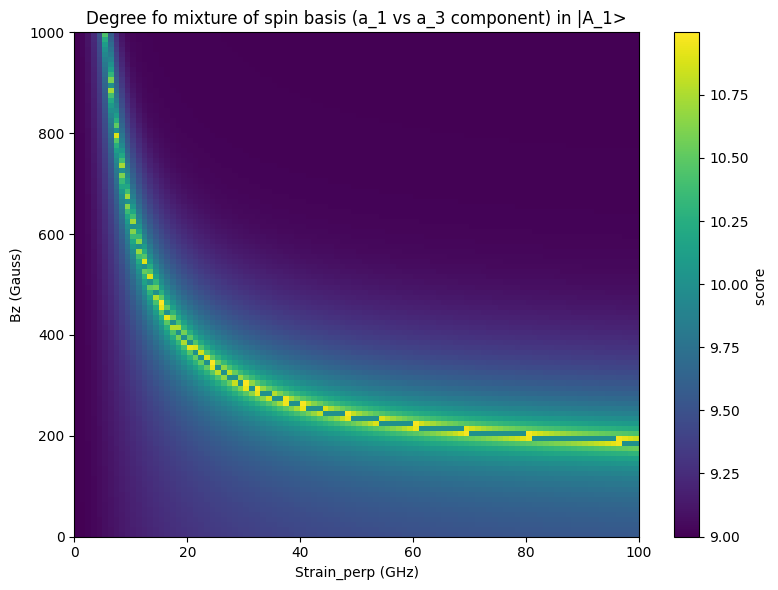

In [5]:

s = 1
making_colormap_spin_basis(s,1,3)

C:\Users\risei\AppData\Local\Temp\ipykernel_14624\1258374352.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k,w] = math.log10(score)


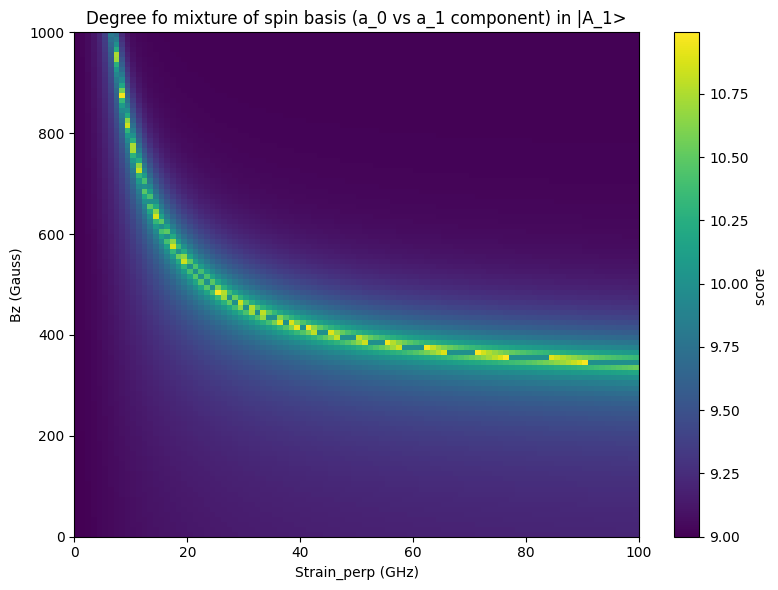

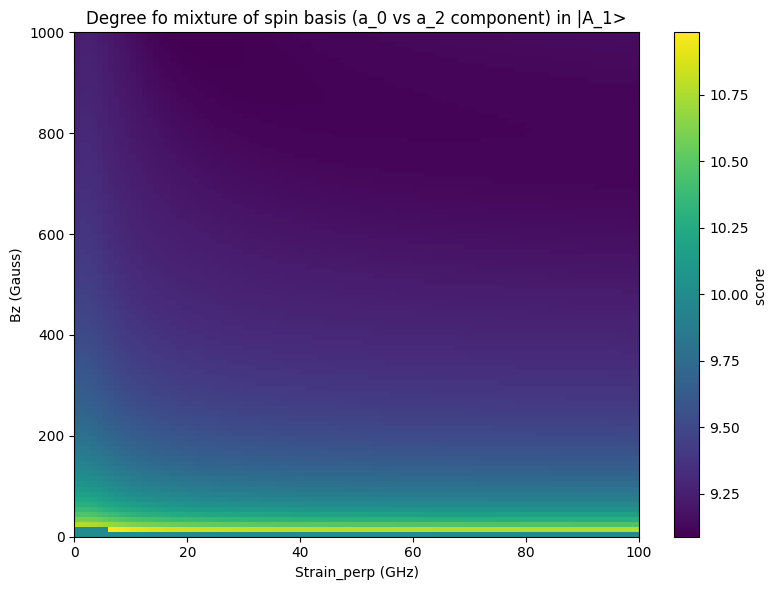

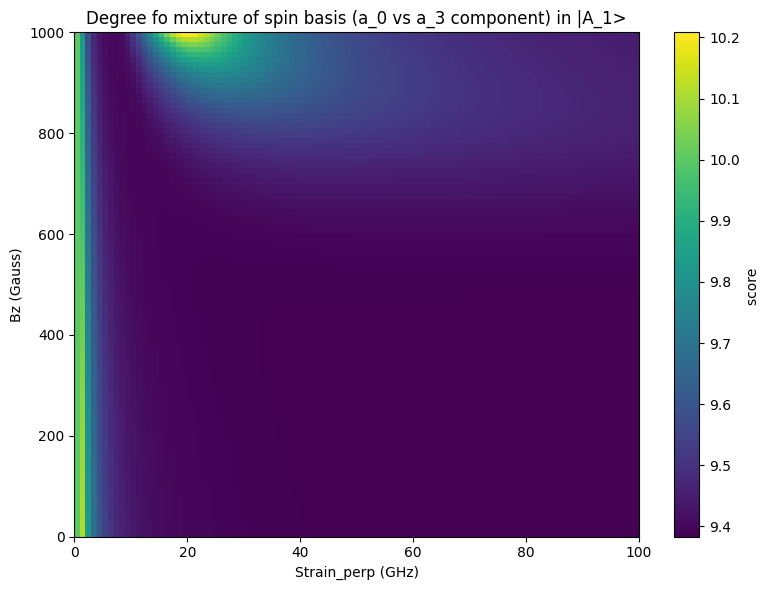

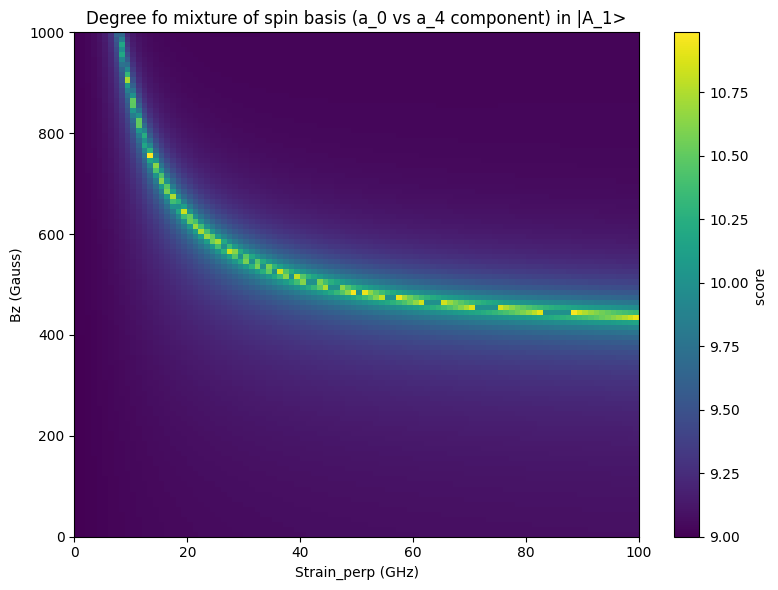

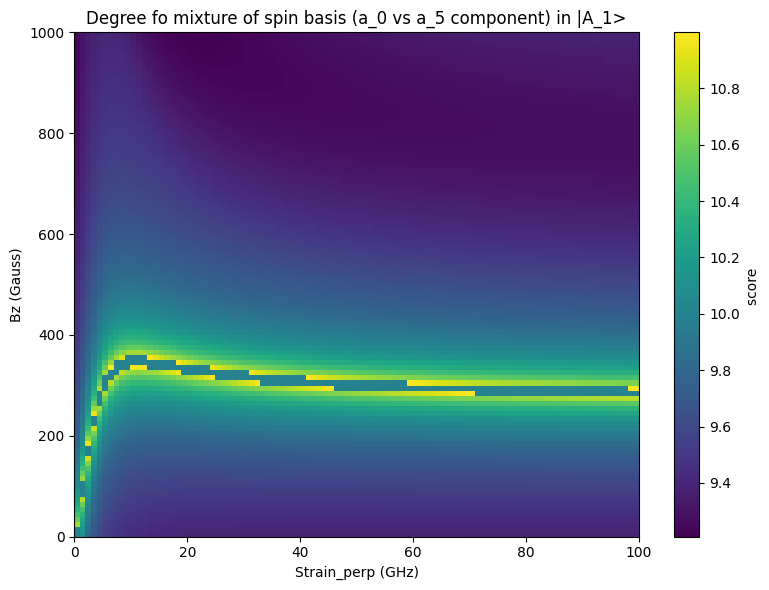

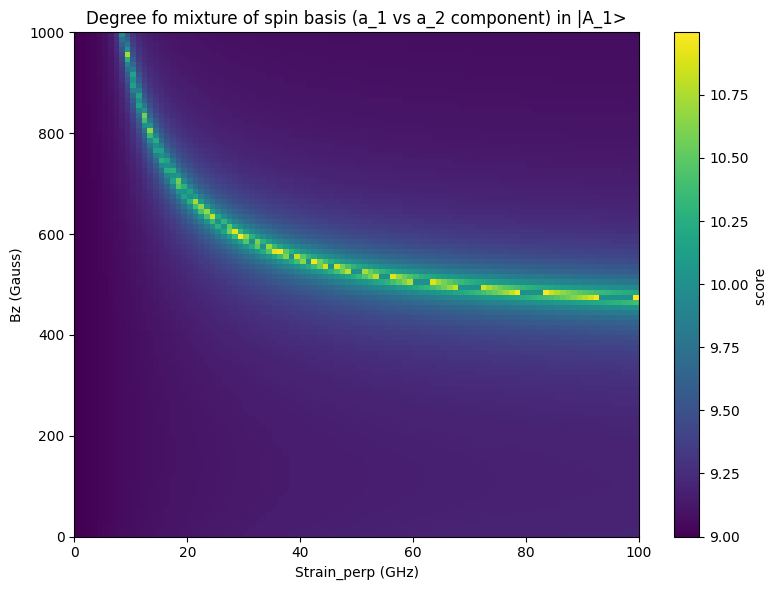

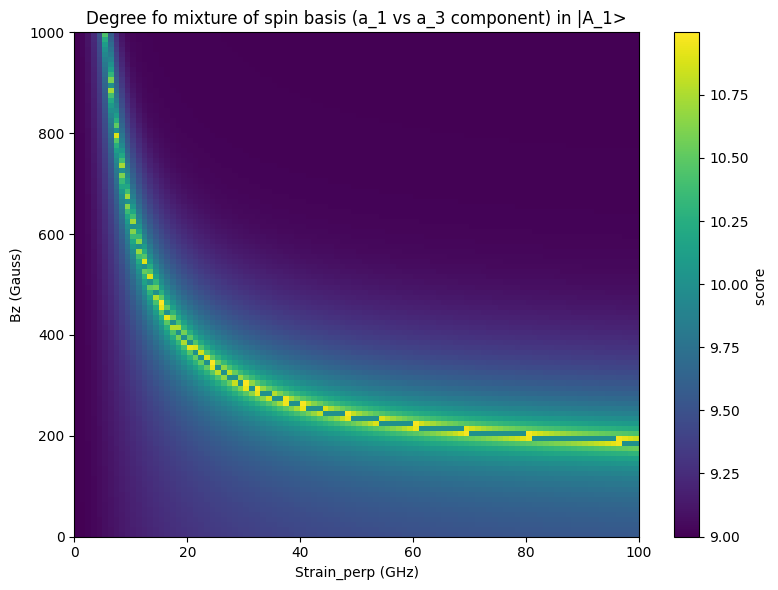

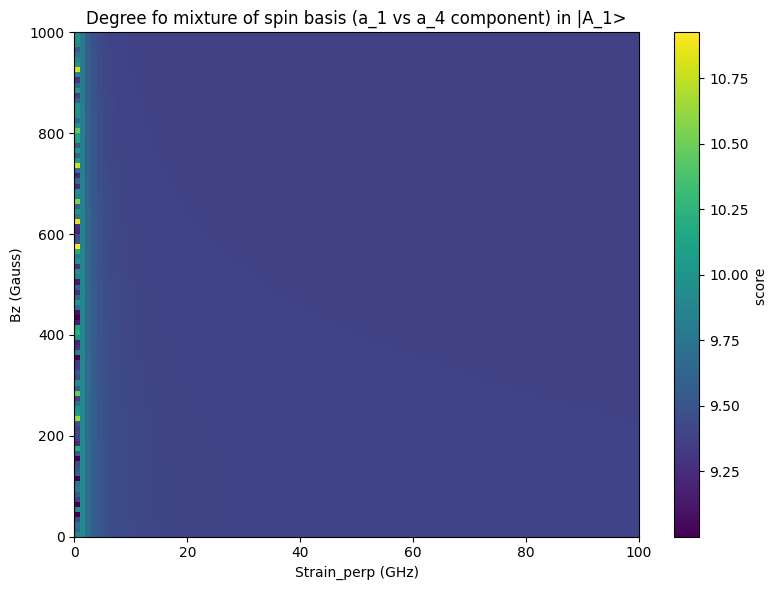

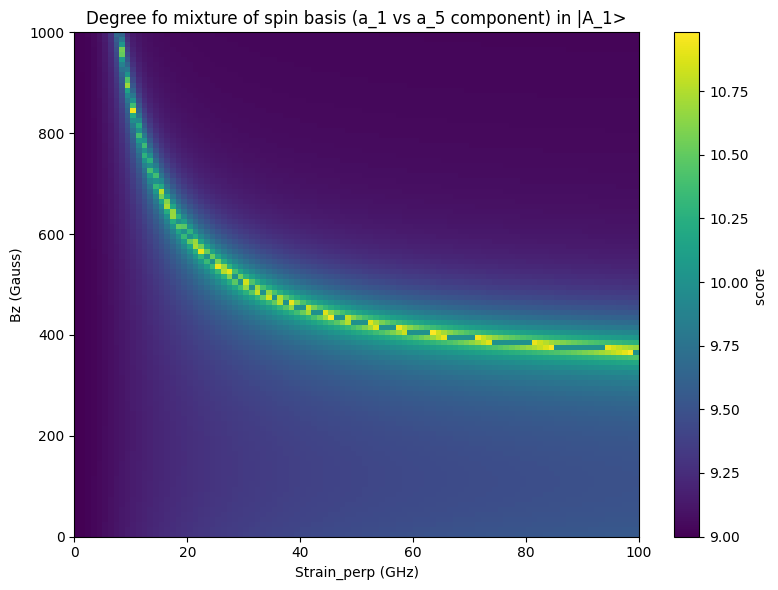

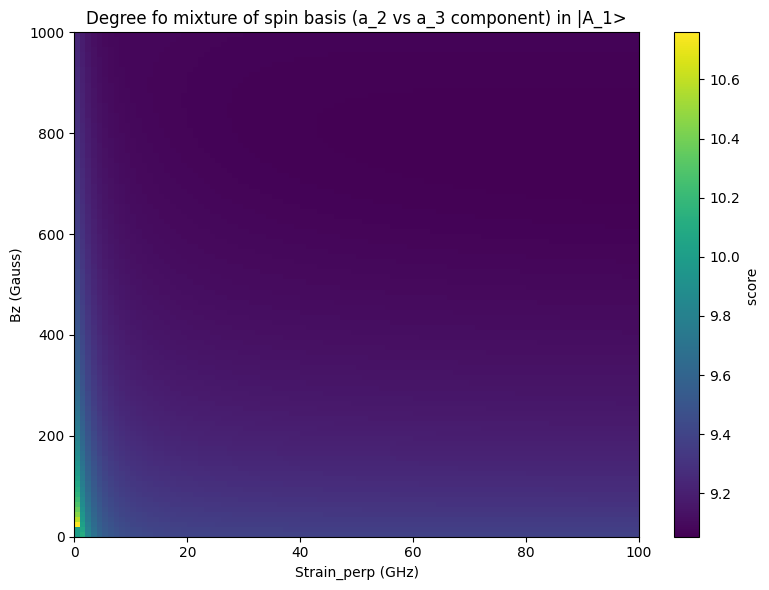

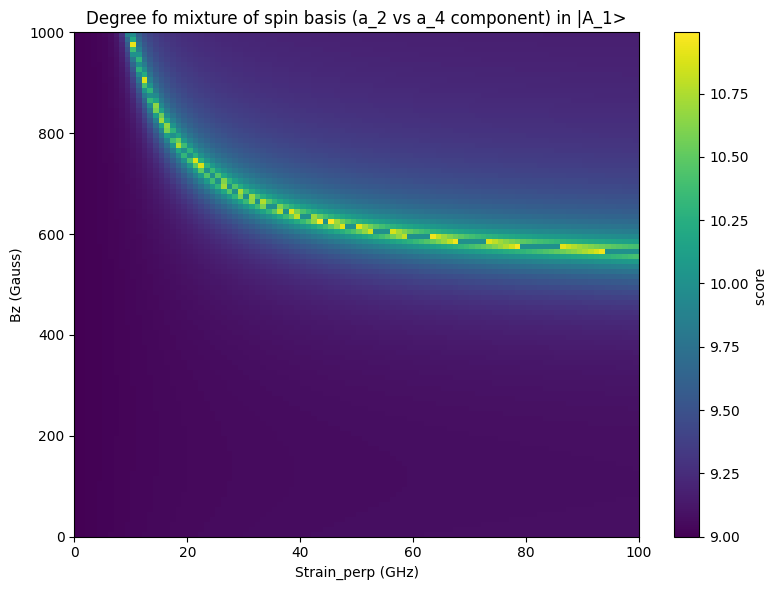

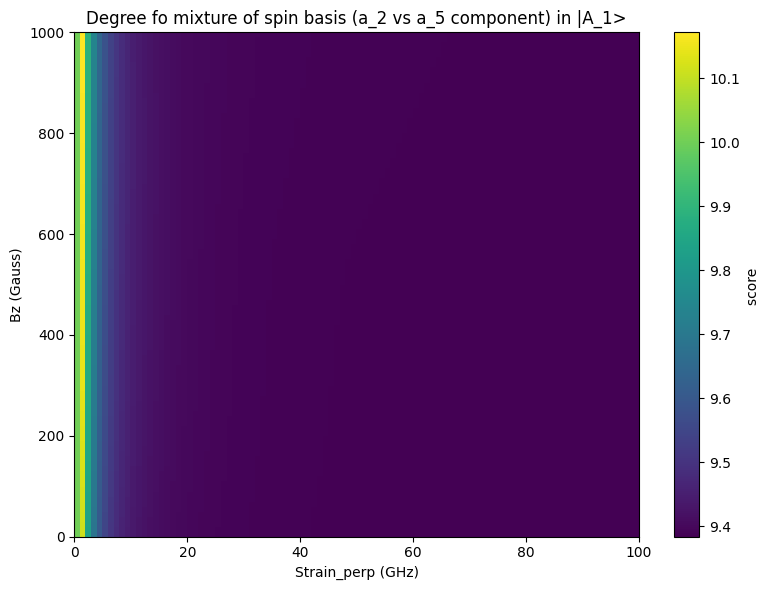

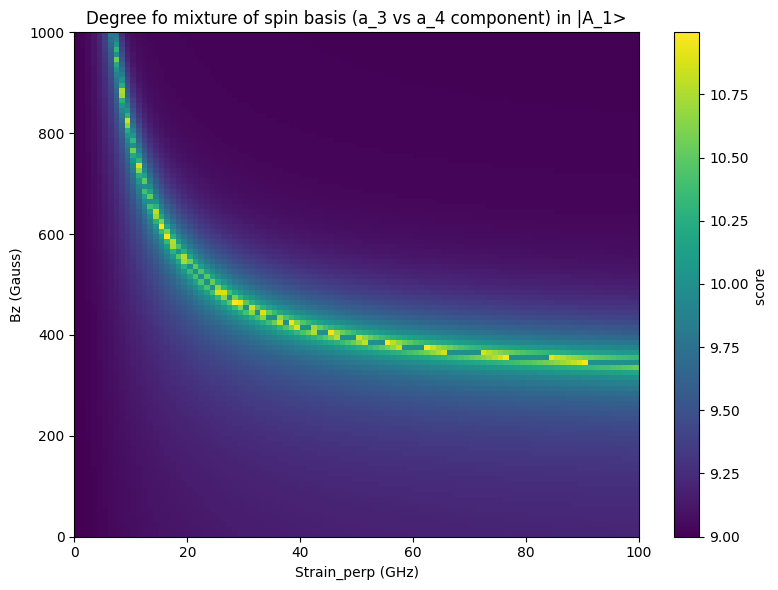

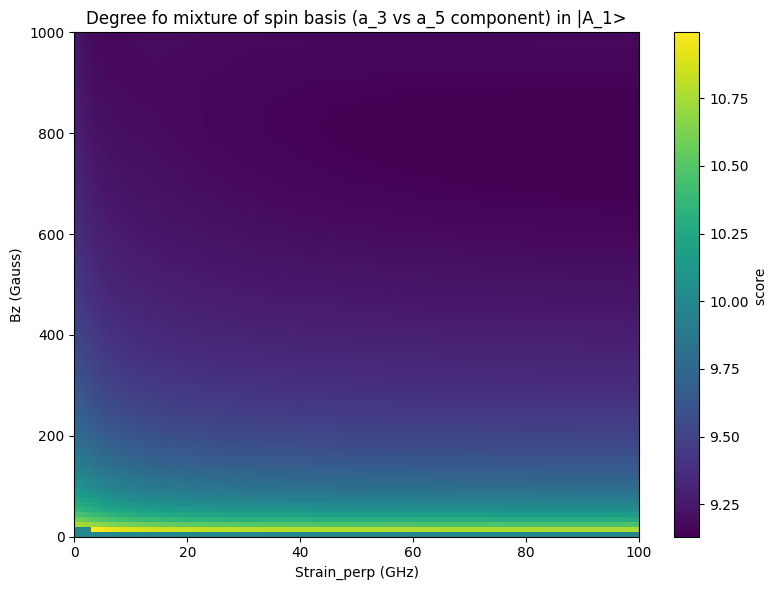

In [ ]:
s = 1


for i in range(0,6):
    for j in range(i,6):
        if i != j:
            making_colormap_spin_basis(s, i, j)